---
title: "MuSiC"
output: html_document
date: "2026-03-26"
---



In [ ]:
knitr::opts_chunk$set(echo = TRUE)


In [1]:
library(ggplot2)
library(ggrepel)
library(ggpubr)
library(stringr)
library(MASS)
library(RColorBrewer)
library(DESeq2)
library(viridis)
library(ggpointdensity)
library(tidyverse)
library(data.table)
library(pheatmap)
library(ComplexHeatmap)
library(UpSetR)
library(readxl)
library(ggsci)
library(ggpointdensity)
library(ggprism)
library(ragg)
library(edgeR)
library(MuSiC)
library(Seurat)
theme_set(theme_classic(base_size = 15))

personal_path = "/fh/working/sun_w/sshen/MorPhiC"
path = "/fh/fast/sun_w/MorPhiC/data/MorPhiC_exchange_experiment/"
dat_path = file.path(path, "DRACC-processed/NW_exchange_experiment_DRACC_processed_March2026/Tables")
sc_ref = readRDS("/fh/working/sun_w/sshen/MorPhiC/HDCA_heart_sc_full_extended.rds")



Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The follo

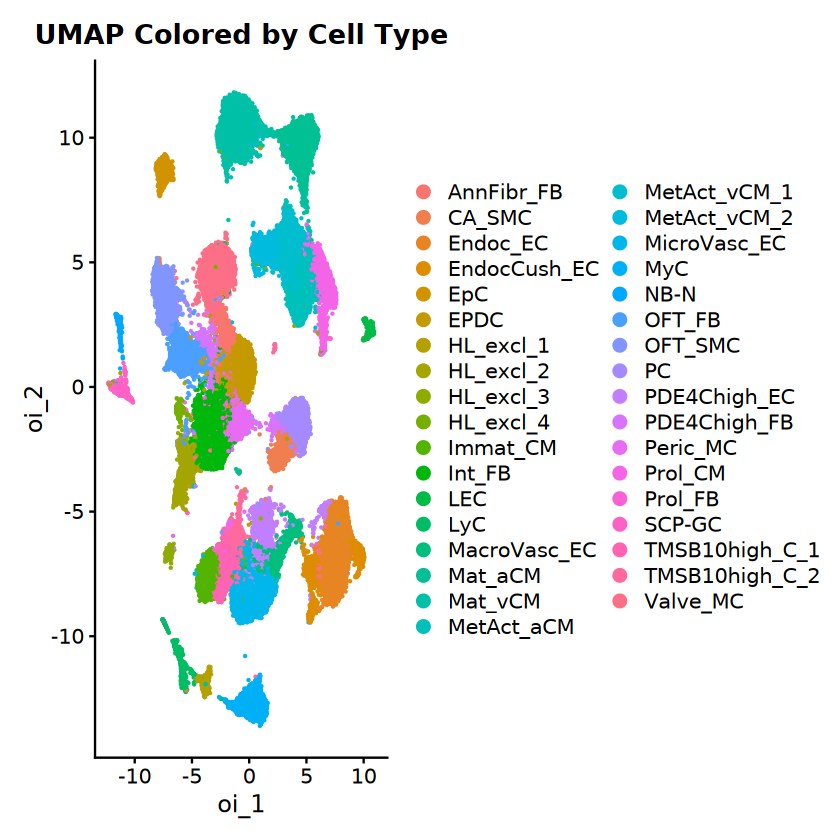

In [2]:
DimPlot(sc_ref, 
        reduction = "umap_oi", 
        group.by = "cell.types") + 
  ggtitle("UMAP Colored by Cell Type")


In [3]:
meta = fread(file.path(personal_path, "NW_meta_data.tsv"), data.table = FALSE)

meta$ko_gene = "WT"
meta$ko_gene[meta$Dcondition == "NW_C39_AUXIN"] = "KO"
meta$ko_gene[meta$Dcondition == "NW_C14_AUXIN"] = "KO"
meta$ko_gene[meta$Dcondition == "JAX_CLONE_DO4"] = "KO"
meta$ko_gene[meta$Dcondition == "JAX_CLONE_AD2"] = "KO"
meta$ko_gene[meta$Dcondition == "MSK_CLONE_05"] = "KO"
meta$ko_gene[meta$Dcondition == "MSK_CLONE_07"] = "KO"
meta$ko_gene[meta$Dcondition == "UCSF_CLONE_D1_DOX"] = "KO"
meta$ko_gene[meta$Dcondition == "UCSF_CLONE_B1 DOX"] = "KO"

cts = fread(file.path(dat_path, "genesCounts.csv"), data.table = FALSE)
colnames(cts) <- gsub("_S[0-9]+_L[0-9]+$", "", colnames(cts))
# Align counts with meta data
stopifnot(
  setequal(meta$Name, names(cts)[-1]),
  !any(duplicated(meta$Name)),
  !any(duplicated(names(cts)[-1]))
)
meta = meta[match(names(cts)[-1], meta$Name), ]
# To matrix
cts_dat = data.matrix(cts[, -1])
rownames(cts_dat) = cts$Name

# Read in gene annotation
gene_anno = fread("/fh/fast/sun_w/sshen/MorPhiC/gencode_v44_primary_assembly_info.tsv")
dim(gene_anno)
cts = cts[cts$Name %in% gene_anno$ensembl_gene_id, ]
cts_dat = cts_dat[rownames(cts_dat) %in% gene_anno$ensembl_gene_id, ]

gene_info = data.frame(
  apply(cts_dat, 1, min), 
  apply(cts_dat, 1, median), 
  apply(cts_dat, 1, \(x) quantile(x, probs = 0.75)), 
  apply(cts_dat, 1, max)
)
gene_info[1:2, ]
names(gene_info) = c("min", "median", "q75", "max")
summary(gene_info)
table(gene_info$q75 > 0)

w2kp = which(gene_info$q75 > 0)
cts_dat = cts_dat[w2kp, ]
gene_info = gene_info[w2kp, ]

# 1) Fill missing HGNC symbols with Ensembl IDs
gene_anno$hgnc_symbol[is.na(gene_anno$hgnc_symbol) | gene_anno$hgnc_symbol == ""] <-
  gene_anno$ensembl_gene_id[is.na(gene_anno$hgnc_symbol) | gene_anno$hgnc_symbol == ""]

# 2) Helper: add "-1", "-2", … only for true duplicates, keeping singletons intact
make_unique_dash <- function(x) {
  ord <- seq_along(x)
  idx_within <- ave(ord, x, FUN = seq_along)
  dup_group <- duplicated(x) | duplicated(x, fromLast = TRUE)
  x_out <- x
  x_out[dup_group] <- paste0(x[dup_group], "-", idx_within[dup_group])
  x_out
}

# 3) Apply across the annotation
gene_anno$hgnc_symbol_unique <- make_unique_dash(gene_anno$hgnc_symbol)

# 4) Map Ensembl IDs → unique HGNC names
map_symbols <- function(ens_ids, anno) {
  anno$hgnc_symbol_unique[match(ens_ids, anno$ensembl_gene_id)]
}

# 5) Replace rownames in DE tables
rownames(cts_dat) <- map_symbols(rownames(cts_dat), gene_anno)


[1] 62754     8

,apply.cts_dat..1..min.,apply.cts_dat..1..median.,apply.cts_dat..1..function.x..quantile.x..probs...0.75..,apply.cts_dat..1..max.
,<int>,<int>,<dbl>,<int>
ENSG00000268674,0,0,0,0
ENSG00000271254,785,1161,1323,1927


      min               median              q75              max         
 Min.   :     0.0   Min.   :     0.0   Min.   :     0   Min.   :      0  
 1st Qu.:     0.0   1st Qu.:     0.0   1st Qu.:     0   1st Qu.:      1  
 Median :     0.0   Median :     2.0   Median :     4   Median :     12  
 Mean   :   546.4   Mean   :   995.9   Mean   :  1210   Mean   :   1871  
 3rd Qu.:   226.2   3rd Qu.:   467.0   3rd Qu.:   574   3rd Qu.:    909  
 Max.   :376699.0   Max.   :589762.0   Max.   :694572   Max.   :1156270  


FALSE  TRUE 
14914 23678 

Creating Relative Abudance Matrix...

Creating Variance Matrix...

Creating Library Size Matrix...

Used 17654 common genes...

Used 35 cell types in deconvolution...

23247XR-05-42 has common genes 16566 ...

23247XR-05-53 has common genes 16782 ...

23247XR-05-55 has common genes 16780 ...

23247XR-05-47 has common genes 16683 ...

23247XR-05-35 has common genes 16620 ...

23247XR-05-41 has common genes 16417 ...

23247XR-05-52 has common genes 16499 ...

23247XR-05-56 has common genes 16735 ...

23247XR-05-05 has common genes 16909 ...

23247XR-05-44 has common genes 16572 ...

23247XR-05-57 has common genes 16745 ...

23247XR-05-37 has common genes 16779 ...

23247XR-05-26 has common genes 16738 ...

23247XR-05-48 has common genes 16601 ...

23247XR-05-43 has common genes 16558 ...

23247XR-05-19 has common genes 16860 ...

23247XR-05-21 has common genes 16959 ...

23247XR-05-17 has common genes 16738 ...

23247XR-05-11 has common genes 16657 ...

23247XR-05-23 has common genes 167

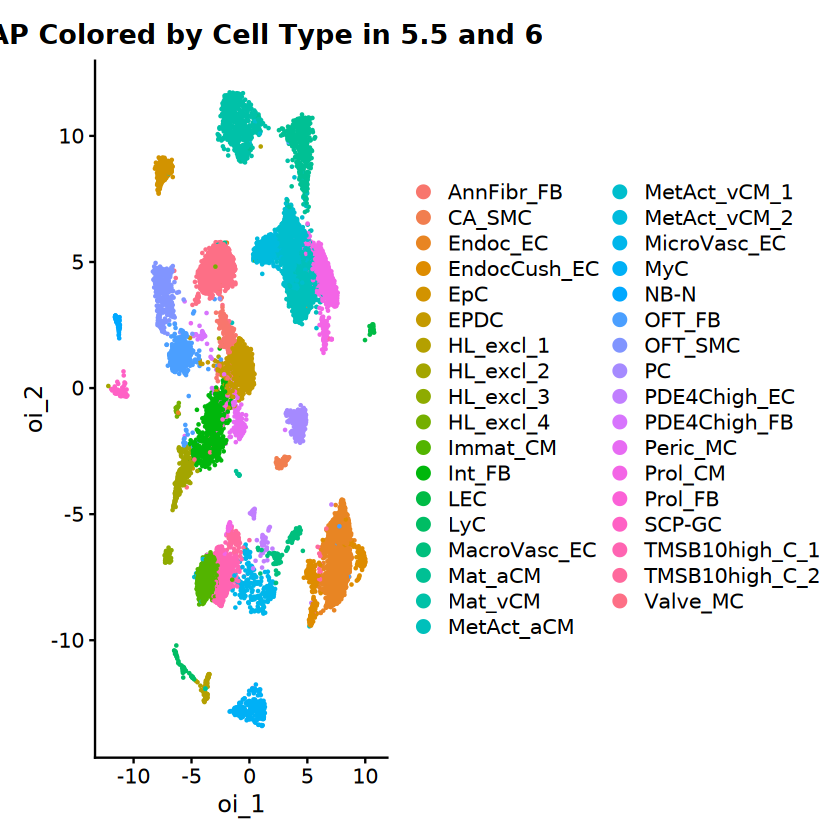

In [4]:
# Convert Seurat to SingleCellExperiment (maintains sparse layers to save RAM)
sc_ref <- subset(sc_ref, subset = age %in% c(5.5, 6))

DimPlot(sc_ref, 
        reduction = "umap_oi", 
        group.by = "cell.types") + 
  ggtitle("UMAP Colored by Cell Type in 5.5 and 6")

sc_sce <- as.SingleCellExperiment(sc_ref)

# Ensure bulk data is a standard matrix (MuSiC requires this)
bulk_matrix <- as.matrix(cts_dat)
# Run the deconvolution
music_results <- music_prop(
  bulk.mtx = bulk_matrix,
  sc.sce = sc_sce,
  clusters = "cell.types", # CHANGE THIS: To your actual cell type column name
  samples = "sampleID", # CHANGE THIS: To your actual sample/subject ID column name
  verbose = TRUE
)


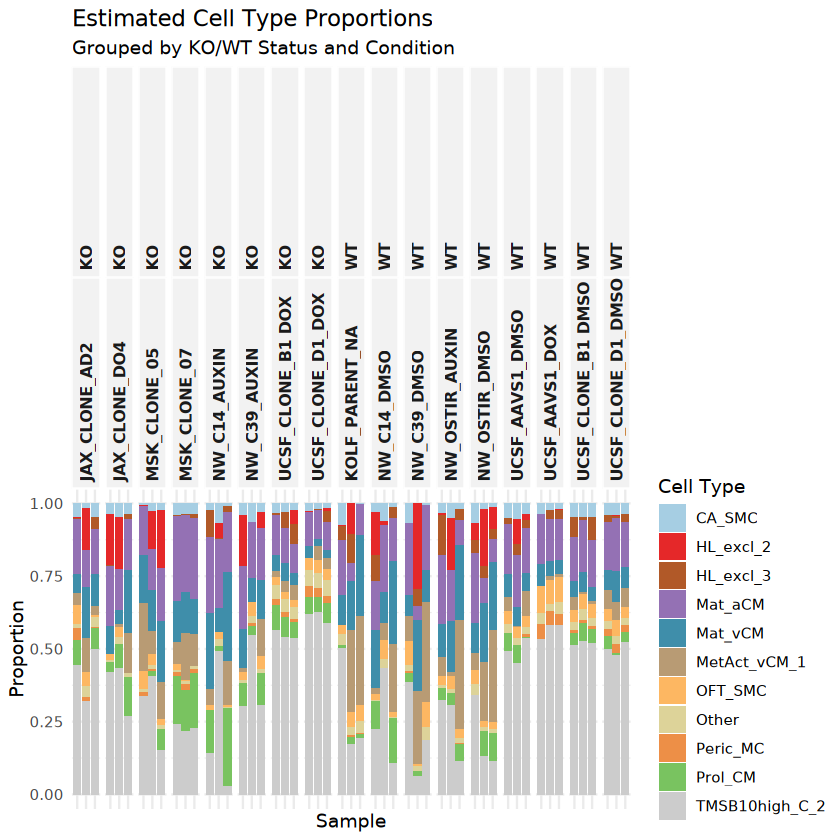

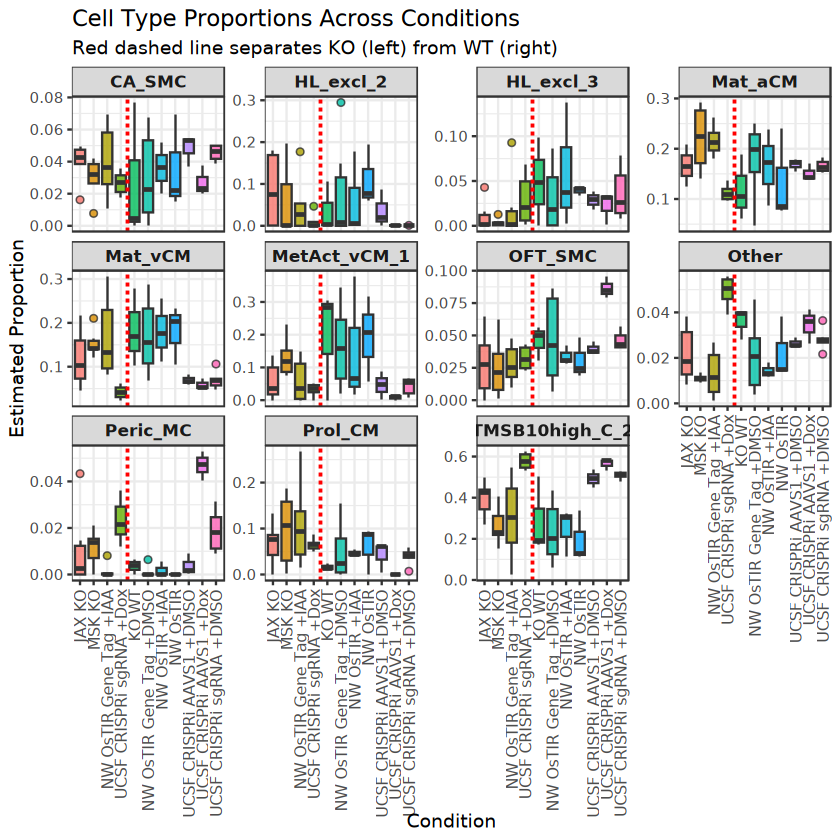

In [5]:
library(ggplot2)
library(tidyr)
library(dplyr)
library(tibble)
library(RColorBrewer)

# 1. Extract the estimated proportions matrix from the MuSiC result
est_prop <- as.data.frame(music_results$Est.prop.weighted)

# Get the names of the cell types (the column names of the proportions matrix)
cell_types <- colnames(est_prop)

# Convert the row names (Sample IDs) into an actual column so we can merge it
est_prop <- rownames_to_column(est_prop, var = "SampleName")

# 2. Merge the proportions with your metadata
# We match the 'SampleName' from proportions to the 'Name' column in 'meta'
merged_data <- merge(est_prop, meta, by.x = "SampleName", by.y = "Name")

# 3. Convert the data from "wide" format to "long" format for ggplot
long_data <- merged_data %>%
  pivot_longer(
    cols = all_of(cell_types), 
    names_to = "CellType", 
    values_to = "Proportion"
  )

# 4. Set your cutoff threshold (e.g., 5%)
threshold <- 0.05

# Find cell types that reach this threshold in AT LEAST ONE sample
keep_cells <- long_data %>%
  group_by(CellType) %>%
  summarize(MaxProp = max(Proportion, na.rm = TRUE)) %>%
  filter(MaxProp >= threshold) %>%
  pull(CellType)

# 5. Create a clean dataset where rare cells become "Other"
long_data_clean <- long_data %>%
  mutate(CellType = ifelse(CellType %in% keep_cells, as.character(CellType), "Other")) %>%
  # PRESERVE ko_gene during summarization
  group_by(SampleName, Dcondition, ko_gene, CellType) %>%
  summarize(Proportion = sum(Proportion, na.rm = TRUE), .groups = "drop")

# 6. Apply Label Mapping
label_map <- c(
  "UCSF_CLONE_D1_DOX"  = "UCSF CRISPRi sgRNA +Dox",
  "UCSF_CLONE_D1_DMSO" = "UCSF CRISPRi sgRNA +DMSO",
  "UCSF_CLONE_B1 DOX"  = "UCSF CRISPRi sgRNA +Dox",
  "UCSF_CLONE_B1 DMSO" = "UCSF CRISPRi sgRNA +DMSO",
  "UCSF_AAVS1_DMSO"    = "UCSF CRISPRi AAVS1 +DMSO",
  "UCSF_AAVS1_DOX"     = "UCSF CRISPRi AAVS1 +Dox",
  "NW_C14_AUXIN"       = "NW OsTIR Gene Tag +IAA",
  "NW_C39_AUXIN"       = "NW OsTIR Gene Tag +IAA",
  "NW_C39_DMSO"        = "NW OsTIR Gene Tag +DMSO",
  "NW_C14_DMSO"        = "NW OsTIR Gene Tag +DMSO",
  "NW_OSTIR_AUXIN"     = "NW OsTIR +IAA",
  "NW_OSTIR_DMSO"      = "NW OsTIR",
  "JAX_CLONE_AD2"      = "JAX KO",
  "JAX_CLONE_DO4"      = "JAX KO",
  "MSK_CLONE_05"       = "MSK KO",
  "MSK_CLONE_07"       = "MSK KO",
  "KOLF_PARENT_NA"     = "KO WT"
)

long_data_clean$plot_label <- label_map[long_data_clean$Dcondition]
long_data_clean <- long_data_clean[!is.na(long_data_clean$plot_label), ]

# 7. Order data by ko_gene (Knockout on Left -> Wild Type on Right)
all_genes <- unique(long_data_clean$ko_gene)

# Move "WT" to the end of the factor levels. 
ko_levels <- c(setdiff(all_genes, "WT"), "WT")

# Create the overarching KO vs WT status column
long_data_clean <- long_data_clean %>%
  mutate(ko_gene = factor(ko_gene, levels = ko_levels)) %>%
  mutate(ko_status = ifelse(ko_gene == "WT", "WT", "KO")) %>%
  mutate(ko_status = factor(ko_status, levels = c("KO", "WT"))) %>%
  arrange(ko_gene, Dcondition, plot_label) 

# Lock in the factor levels for plotting variables strictly based on the sorted dataframe
long_data_clean <- long_data_clean %>%
  mutate(
    Dcondition = factor(Dcondition, levels = unique(Dcondition)),
    plot_label = factor(plot_label, levels = unique(plot_label)),
    SampleName = factor(SampleName, levels = unique(SampleName))
  )

# Calculate where to draw the boundary line for the boxplots
ko_count <- length(unique(long_data_clean$plot_label[long_data_clean$ko_status == "KO"]))

# 8. Setup Shuffled Colors
n_colors <- length(unique(long_data_clean$CellType[long_data_clean$CellType != "Other"]))
base_palette <- colorRampPalette(brewer.pal(12, "Paired"))(n_colors)

set.seed(42) 
distinct_colors <- sample(base_palette)

if ("Other" %in% unique(long_data_clean$CellType)) {
  final_colors <- c(distinct_colors, "grey80")
} else {
  final_colors <- distinct_colors
}

# 9. Plot 1: Bar Plot (Two-Tiered Facets)
p1 <- ggplot(long_data_clean, aes(x = SampleName, y = Proportion, fill = CellType)) +
  geom_bar(stat = "identity", position = "stack", width = 0.8) +
  
  # Two-level header: KO/WT on top, condition underneath
  facet_grid(~ ko_status + Dcondition, scales = "free_x", space = "free_x") +
  
  scale_fill_manual(values = final_colors) +
  theme_minimal() +
  theme(
    strip.text.x = element_text(angle = 90, vjust = 0.5, hjust = 0, size = 9, face = "bold"), 
    axis.text.x = element_blank(),  
    axis.ticks.x = element_blank(),
    panel.spacing = unit(0.2, "lines"), 
    strip.background = element_rect(fill = "grey95", color = "white") 
  ) +
  labs(
    title = "Estimated Cell Type Proportions",
    subtitle = "Grouped by KO/WT Status and Condition", 
    x = "Sample",
    y = "Proportion",
    fill = "Cell Type"
  )

print(p1)

# 10. Plot 2: Box Plots (With Boundary Line)
p2 <- ggplot(long_data_clean, aes(x = plot_label, y = Proportion, fill = plot_label)) +
  geom_boxplot(outlier.shape = 21, outlier.size = 1.5, alpha = 0.8) +
  
  # Draw a vertical dashed line separating KO and WT
  geom_vline(xintercept = ko_count + 0.5, linetype = "dashed", color = "red", linewidth = 0.8) +
  
  facet_wrap(~ CellType, scales = "free_y", ncol = 4) +
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 9),
    strip.text = element_text(face = "bold", size = 10),
    legend.position = "none" 
  ) +
  labs(
    title = "Cell Type Proportions Across Conditions",
    subtitle = "Red dashed line separates KO (left) from WT (right)",
    x = "Condition",
    y = "Estimated Proportion"
  )

print(p2)


As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.
Names of identity class contain underscores ('_'), replacing with dashes ('-')
This message is displayed once every 8 hours.


Number of dead samples removed: 0 


Creating Relative Abudance Matrix...

Creating Variance Matrix...

Creating Library Size Matrix...

Used 17491 common genes...

Used 35 cell types in deconvolution...

23247XR-05-42 has common genes 17389 ...

23247XR-05-53 has common genes 17375 ...

23247XR-05-55 has common genes 17378 ...

23247XR-05-47 has common genes 17389 ...

23247XR-05-35 has common genes 17395 ...

23247XR-05-41 has common genes 17396 ...

23247XR-05-52 has common genes 17366 ...

23247XR-05-56 has common genes 17355 ...

23247XR-05-05 has common genes 17479 ...

23247XR-05-44 has common genes 17389 ...

23247XR-05-57 has common genes 17387 ...

23247XR-05-37 has common genes 17323 ...

23247XR-05-26 has common genes 17353 ...

23247XR-05-48 has common genes 17389 ...

23247XR-05-43 has common genes 17367 ...

23247XR-05-19 has common genes 17352 ...

23247XR-05-21 has common genes 17395 ...

23247XR-05-17 has common genes 17465 ...

23247XR-05-11 has common genes 17396 ...

23247XR-05-23 has common genes 173

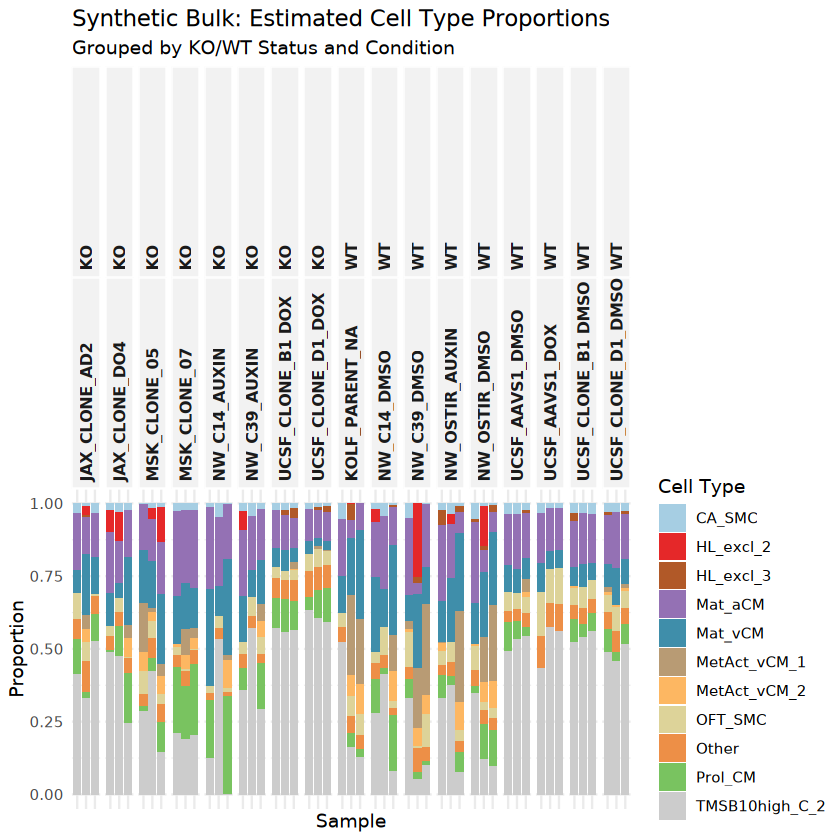

In [6]:
# Note: If you are using Seurat v5, use layer = "counts". For Seurat v4, use slot = "counts".
# We use raw counts (linear scale) because bulk RNA-seq is a linear sum of cells.
cell_type_profiles <- AverageExpression(sc_ref, assays = "RNA", layer = "counts", group.by = 'cell.types')$RNA
colnames(cell_type_profiles) = gsub("-", "_", colnames(cell_type_profiles))
# 2. Extract your previously estimated weights (proportions)
est_weights <- as.matrix(music_results$Est.prop.weighted)

# 3. Align the cell types to ensure the matrix math works perfectly
common_celltypes <- intersect(colnames(cell_type_profiles), colnames(est_weights))
P <- as.matrix(cell_type_profiles[, common_celltypes]) # Profiles (Genes x CellTypes)
W <- est_weights[, common_celltypes]                   # Weights (Samples x CellTypes)

# 4. Create the synthetic bulk via matrix multiplication
# We transpose W so it is (CellTypes x Samples)
synthetic_bulk <- P %*% t(W) 
synthetic_bulk = synthetic_bulk[rowSums(synthetic_bulk) > 0, ]

common_genes <- intersect(rownames(synthetic_bulk), rownames(cts_dat))

# 2. Subset the synthetic bulk to only include these genes
synthetic_bulk_filtered <- synthetic_bulk[common_genes, ]

# 3. As an extra safety net, remove any remaining genes that sum to exactly 0 
# across all synthetic samples (this prevents the internal divide-by-zero)
synthetic_bulk_filtered <- synthetic_bulk_filtered[rowSums(synthetic_bulk_filtered) > 0, ]

# 4. Run MuSiC on the filtered synthetic bulk
zero_sum_samples <- colSums(synthetic_bulk_filtered) == 0

# (Optional) Print out how many and which samples are causing the crash
cat("Number of dead samples removed:", sum(zero_sum_samples), "\n")
if(sum(zero_sum_samples) > 0) {
  print(colnames(synthetic_bulk_filtered)[zero_sum_samples])
}

# 2. Subset the matrix to KEEP only the samples that DO NOT sum to zero
synthetic_bulk_cleaned <- synthetic_bulk_filtered[, !zero_sum_samples]

# 3. Run MuSiC one last time
synthetic_music_results <- music_prop(
  bulk.mtx = synthetic_bulk_cleaned,
  sc.sce = sc_sce,        
  clusters = "cell.types", 
  samples = "sampleID", 
  verbose = TRUE
)

# You can extract these new proportions to compare against the originals later
synth_est_prop <- synthetic_music_results$Est.prop.weighted

library(ggplot2)
library(tidyr)
library(dplyr)
library(tibble)
library(RColorBrewer)

# 1. Extract the synthetic proportions matrix
synth_df <- as.data.frame(synth_est_prop)

# Get the names of the cell types
synth_cell_types <- colnames(synth_df)

# Convert row names to SampleName column
synth_df <- rownames_to_column(synth_df, var = "SampleName")

# 2. Merge with metadata
merged_synth <- merge(synth_df, meta, by.x = "SampleName", by.y = "Name")

# 3. Convert to long format
long_synth <- merged_synth %>%
  pivot_longer(
    cols = all_of(synth_cell_types), 
    names_to = "CellType", 
    values_to = "Proportion"
  )

# 4. Set threshold and determine which cells to keep (using 5% as before)
threshold <- 0.05
keep_cells_synth <- long_synth %>%
  group_by(CellType) %>%
  summarize(MaxProp = max(Proportion, na.rm = TRUE)) %>%
  filter(MaxProp >= threshold) %>%
  pull(CellType)

# 5. Clean dataset (Rare cells -> "Other")
synth_long_data_clean <- long_synth %>%
  mutate(CellType = ifelse(CellType %in% keep_cells_synth, as.character(CellType), "Other")) %>%
  group_by(SampleName, Dcondition, ko_gene, CellType) %>%
  summarize(Proportion = sum(Proportion, na.rm = TRUE), .groups = "drop")

# 6. Apply Label Mapping
label_map <- c(
  "UCSF_CLONE_D1_DOX"  = "UCSF CRISPRi sgRNA +Dox",
  "UCSF_CLONE_D1_DMSO" = "UCSF CRISPRi sgRNA +DMSO",
  "UCSF_CLONE_B1 DOX"  = "UCSF CRISPRi sgRNA +Dox",
  "UCSF_CLONE_B1 DMSO" = "UCSF CRISPRi sgRNA +DMSO",
  "UCSF_AAVS1_DMSO"    = "UCSF CRISPRi AAVS1 +DMSO",
  "UCSF_AAVS1_DOX"     = "UCSF CRISPRi AAVS1 +Dox",
  "NW_C14_AUXIN"       = "NW OsTIR Gene Tag +IAA",
  "NW_C39_AUXIN"       = "NW OsTIR Gene Tag +IAA",
  "NW_C39_DMSO"        = "NW OsTIR Gene Tag +DMSO",
  "NW_C14_DMSO"        = "NW OsTIR Gene Tag +DMSO",
  "NW_OSTIR_AUXIN"     = "NW OsTIR +IAA",
  "NW_OSTIR_DMSO"      = "NW OsTIR",
  "JAX_CLONE_AD2"      = "JAX KO",
  "JAX_CLONE_DO4"      = "JAX KO",
  "MSK_CLONE_05"       = "MSK KO",
  "MSK_CLONE_07"       = "MSK KO",
  "KOLF_PARENT_NA"     = "KO WT"
)

synth_long_data_clean$plot_label <- label_map[synth_long_data_clean$Dcondition]
synth_long_data_clean <- synth_long_data_clean[!is.na(synth_long_data_clean$plot_label), ]

# 7. Order data by ko_gene (Knockout on Left -> Wild Type on Right)
all_genes_synth <- unique(synth_long_data_clean$ko_gene)
ko_levels_synth <- c(setdiff(all_genes_synth, "WT"), "WT")

# Apply overarching KO vs WT status and sort
synth_long_data_clean <- synth_long_data_clean %>%
  mutate(ko_gene = factor(ko_gene, levels = ko_levels_synth)) %>%
  mutate(ko_status = ifelse(ko_gene == "WT", "WT", "KO")) %>%
  mutate(ko_status = factor(ko_status, levels = c("KO", "WT"))) %>%
  arrange(ko_gene, Dcondition, plot_label) 

# Lock in factor levels
synth_long_data_clean <- synth_long_data_clean %>%
  mutate(
    Dcondition = factor(Dcondition, levels = unique(Dcondition)),
    plot_label = factor(plot_label, levels = unique(plot_label)),
    SampleName = factor(SampleName, levels = unique(SampleName))
  )

# 8. Setup Shuffled Colors (Kept identical to previous seed so colors match the original graph)
n_colors_synth <- length(unique(synth_long_data_clean$CellType[synth_long_data_clean$CellType != "Other"]))
base_palette_synth <- colorRampPalette(brewer.pal(12, "Paired"))(n_colors_synth)

set.seed(42) 
distinct_colors_synth <- sample(base_palette_synth)

if ("Other" %in% unique(synth_long_data_clean$CellType)) {
  final_colors_synth <- c(distinct_colors_synth, "grey80")
} else {
  final_colors_synth <- distinct_colors_synth
}

# 9. Plot 1: Bar Plot for Synthetic Data
p_synth <- ggplot(synth_long_data_clean, aes(x = SampleName, y = Proportion, fill = CellType)) +
  geom_bar(stat = "identity", position = "stack", width = 0.8) +
  
  # Two-level header: KO/WT on top, condition underneath
  facet_grid(~ ko_status + Dcondition, scales = "free_x", space = "free_x") +
  
  scale_fill_manual(values = final_colors_synth) +
  theme_minimal() +
  theme(
    strip.text.x = element_text(angle = 90, vjust = 0.5, hjust = 0, size = 9, face = "bold"), 
    axis.text.x = element_blank(),  
    axis.ticks.x = element_blank(),
    panel.spacing = unit(0.2, "lines"), 
    strip.background = element_rect(fill = "grey95", color = "white") 
  ) +
  labs(
    title = "Synthetic Bulk: Estimated Cell Type Proportions", # Updated Title
    subtitle = "Grouped by KO/WT Status and Condition", 
    x = "Sample",
    y = "Proportion",
    fill = "Cell Type"
  )

print(p_synth)


In [7]:
# Find the genes that overlap between your true bulk and your synthetic bulk
common_genes <- intersect(rownames(cts_dat), rownames(synthetic_bulk))

# 1. Correlate Original Bulk vs. Synthetic Bulk (Sample by Sample)
orig_vs_synth_cor <- sapply(colnames(synthetic_bulk), function(sample_name) {
  if(sample_name %in% colnames(cts_dat)) {
    cor(cts_dat[common_genes, sample_name], 
        synthetic_bulk[common_genes, sample_name], 
        method = "spearman") 
  } else {
    NA
  }
})

# Print the summary of how well the synthetic bulk reconstructed the true bulk
print("Summary of Original vs. Synthetic Correlations:")
summary(orig_vs_synth_cor)


[1] "Summary of Original vs. Synthetic Correlations:"


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.7827  0.7957  0.8015  0.8069  0.8206  0.8379 

In [9]:
library(ggplot2)
library(dplyr)
library(tibble)
library(dplyr)
library(tidyr)

# 1. Extract the estimated proportion matrices from both runs
prop_orig <- music_results$Est.prop.weighted
prop_synth <- synthetic_music_results$Est.prop.weighted

# 2. Find overlapping samples and cell types 
# (Crucial, because we removed some samples to fix the zero-sum error)
common_samples <- intersect(rownames(prop_orig), rownames(prop_synth))
common_celltypes <- intersect(colnames(prop_orig), colnames(prop_synth))

# Subset both matrices so they match perfectly
p_orig_aligned <- prop_orig[common_samples, common_celltypes]
p_synth_aligned <- prop_synth[common_samples, common_celltypes]

# 3. Calculate Overall Correlation (Flattening both matrices)
# We use Pearson here because we are looking for a direct linear relationship (y = x)
overall_cor <- cor(as.vector(p_orig_aligned), as.vector(p_synth_aligned), method = "pearson")
cat("Overall Pearson Correlation (Proportions):", round(overall_cor, 4), "\n")

# 4. Calculate Sample-by-Sample Correlation
sample_prop_cors <- sapply(common_samples, function(s) {
  cor(p_orig_aligned[s, ], p_synth_aligned[s, ], method = "pearson")
})

print("Summary of Sample-by-Sample Proportion Correlations:")
summary(sample_prop_cors)

# 1. We already have 'sample_prop_cors' from the previous code block.
# Let's turn that named vector into a clean data frame.
cor_df <- data.frame(
  SampleName = names(sample_prop_cors),
  Correlation = as.numeric(sample_prop_cors)
)

# 2. Merge it with your metadata so we can color-code by Condition
cor_df <- merge(cor_df, meta, by.x = "SampleName", by.y = "Name", all.x = TRUE)


Overall Pearson Correlation (Proportions): 0.9728 
[1] "Summary of Sample-by-Sample Proportion Correlations:"


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.9159  0.9539  0.9731  0.9685  0.9906  0.9985 